# Exercise - Duration

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1 Stylized Duration and Convexity

Consider a bond issued today, with
* 10 years to maturity
* coupon rate of 3%
* yield to maturity (semiannual) is 5\%


### 1.1.

Calculate duration as given in the formula.

### 1.2.
Re-calculate the duration but now assuming the coupon is 7%. (Leave the other parameters the same.)

### 1.3.
Re-calculate the duration but now assuming the coupon is 5%. (Leave the other parameters the same.)

### 1.4.
Compare the answers. How does coupon rate impact duration. Explain.

In [4]:
#Helper Function to Calculate Macaulay Duration

def calc_duration(
    maturity_years,
    coupon_rate,
    ytm,
    face=100,
    freq=2
):
    """
    Computes Macaulay duration of a coupon bond using cashflow weights.
    """
    
    # Number of periods
    n = int(maturity_years * freq)
    
    # Cash flows
    coupon = face * coupon_rate / freq
    cashflows = np.full(n, coupon)
    cashflows[-1] += face  # add principal at maturity
    
    # Time in years
    times = np.arange(1, n + 1) / freq
    
    # Discount factors
    y = ytm / freq
    discount_factors = (1 + y) ** (-np.arange(1, n + 1))
    
    # Bond price
    price = np.sum(cashflows * discount_factors)
    
    # Weights (PV of CF / price)
    weights = (cashflows * discount_factors) / price
    
    # Macaulay duration
    duration = np.sum(weights * times)
    
    return duration


In [8]:
#1.1:
answer_1_1 = calc_duration(maturity_years=10,coupon_rate=0.03,ytm=0.05)
display(answer_1_1.round(4))

8.5709

In [ ]:
#1.2: change coupon rate to 7%
answer_1_2 = calc_duration(maturity_years=10,coupon_rate=0.07,ytm=0.05)
display(answer_1_2.round(4))

7.5648

In [10]:
#1.3: change coupon rate to 5%
answer_1_3 = calc_duration(maturity_years=10,coupon_rate=0.05,ytm=0.05)
display(answer_1_3.round(4))

7.9894

1.4: 
From parts 1.1, 1.2, and 1.3 we observe that as we increase the coupon rate, the duration decreases. This is because higher coupons pay more of the bond's value earlier, shifting more weight to earlier cash flows and pulling the average time forward, ultimately lowering duration.

***

# 2 Hedging Duration

Use data from `../data/treasury_ts_duration_2025-05-30.xlsx`.

The file contains time-series information on two treasuries. 

In [11]:
import pandas as pd

In [12]:
QUOTE_DATE = '2025-05-30'
filepath = f'treasury_ts_duration_{QUOTE_DATE}.xlsx'

data = pd.read_excel(filepath,sheet_name='database')
data_info =  data.drop_duplicates(subset='KYTREASNO', keep='first').set_index('KYTREASNO')
data_info[['type','issue date','maturity date','cpn rate']]

,type,issue date,maturity date,cpn rate
KYTREASNO,,,,
207391,note,2019-08-15,2029-08-15,1.625
207392,bond,2019-08-15,2049-08-15,2.250


You will largely focus on the sheets which give the timeseries of prices and durations for each of the two securities, as shown in the following code.

In [13]:
SHEET_CLEAN = 'clean price'
SHEET_DIRTY = 'dirty price'
SHEET_DURATION = 'duration'
INDEX_NAME = 'quote date'

clean = pd.read_excel(filepath,sheet_name=SHEET_CLEAN).set_index(INDEX_NAME)
dirty = pd.read_excel(filepath,sheet_name=SHEET_DIRTY).set_index(INDEX_NAME)
duration = pd.read_excel(filepath,sheet_name=SHEET_DURATION).set_index(INDEX_NAME)

Set prices to clean or dirty...

In [14]:
USE_CLEAN = True

if USE_CLEAN:
    price = clean
else:
    price = dirty

In [15]:
display(price)

,207391,207392
quote date,,
2019-08-09,98.882812,99.789062
2019-08-12,99.796875,102.554688
2019-08-13,99.281250,101.867188
2019-08-14,100.406250,105.179688
2019-08-15,100.882812,106.234375
...,...,...
2025-05-23,90.904697,59.948053
2025-05-27,91.035156,60.871094
2025-05-28,90.910156,60.542969


Duration...

In [16]:
display(duration)

,207391,207392
quote date,,
2019-08-09,9.289497,22.000102
2019-08-12,9.285468,22.118496
2019-08-13,9.280314,22.084308
2019-08-14,9.282750,22.228549
2019-08-15,9.282163,22.270910
...,...,...
2025-05-23,4.081232,16.706728
2025-05-27,4.070393,16.764143
2025-05-28,4.067509,16.736880


### 2.1.

Suppose you have a portfolio of `10,000` USD long in security `207391` on the first day of the sample.

If you want to manage interest rate exposure using duration, how large of a short position should you hold in `207392`?

### 2.2.

Step through the time-series, doing the following:

* Starting at the end of the first day, set the hedged position according to the relative given durations.
* Use the second day's price data to evaluate the net profit or loss of the hedged position.
* Reset the the hedged position using the end-of-second-day durations. Again fix the long position of security `207391` to be `10,000`.
* Repeat throughout the timeseries.

Calculate the daily profit and loss (PnL) for the
* dynamically hedged position constructed above.
* long-only position, (still at `10,000` throughout.)

(You might check to verify that the net duration is zero at all dates.)

Report...
* the cumulative PnL of both strategies via a plot.
* the (daily) mean, standard deviation, min, and max of the PnL in a table.

### 2.3.

Give two reasons that the daily PnL is not always zero for the hedged position given that we have hedged the duration.

### 2.4. 
The PnL above doesn't account for the coupons.

Calculate a dataframe indexed by dates with columns for the two treasuries with values of coupon payments. 
* Recall that the stated coupon rate is semiannual, so at any give coupon date, it pays half the stated rate.
* Figure out the coupon dates by using the `data` tab and looking for dates where `acc int` goes down. Recall that accrued interest measures the portion of the coupon period that has passed. So when this resets, it is because the coupon has been paid.

Report the first 5 dates that a coupon is paid (by either bond).

### 2.5. 
Account for the coupons in the PnL calculations of `2.2`. Report the updated PnL in a plot and a table, similar to the reporting in `2.2`.

## 2.1

In [23]:
id_long  = 207391
id_short = 207392
V_long = 10_000

# pull durations on the quote date
D_long  = float(duration.loc[QUOTE_DATE, id_long])
D_short = float(duration.loc[QUOTE_DATE, id_short])

# $ market value to short (positive number = size of the short position)
V_short = V_long * (D_long / D_short)

print(f'Short Position in 207392: ${V_short:.3f}')

Short Position in 207392: $2421.083


## 2.2

Max abs net dollar duration (should be ~0): 1.4551915228366852e-11


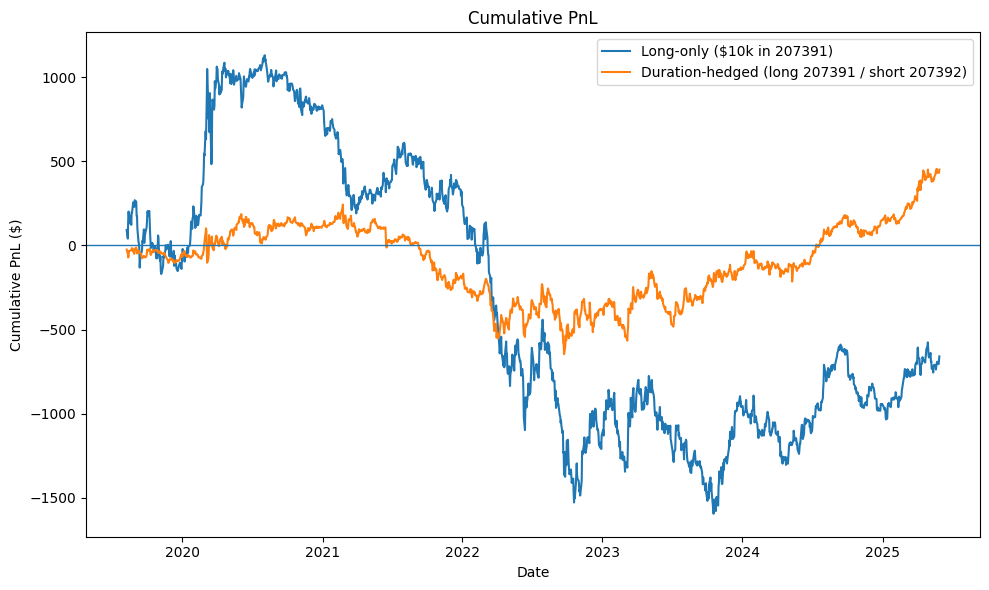

,mean,std,min,max
pnl_long_only,-0.454,43.283,-321.204,276.272
pnl_hedged,0.310,20.852,-98.341,118.431


,V_short,pnl_long_only,pnl_hedged,net_dollar_duration
quote date,,,,
2025-05-22,2445.187,12.737,8.395,0.0
2025-05-23,2442.867,14.351,-23.262,0.0
2025-05-27,2428.035,-13.731,-0.643,0.0
2025-05-28,2430.267,23.418,0.211,0.0
2025-05-29,2422.995,22.291,19.194,0.0


In [27]:
id_long  = 207391
id_short = 207392
V_long_target = 10_000.0  # $ market value long each day

# Align and keep only the two bonds we need
px = price[[id_long, id_short]].copy()
dur = duration[[id_long, id_short]].copy()

# Keep only dates where we have both prices and durations
df = px.join(dur, how="inner", lsuffix="_px", rsuffix="_dur").dropna()
df.columns = [f"{id_long}_px", f"{id_short}_px", f"{id_long}_dur", f"{id_short}_dur"]

# We'll compute PnL from t -> t+1, so we need next-day prices
df["long_px_next"]  = df[f"{id_long}_px"].shift(-1)
df["short_px_next"] = df[f"{id_short}_px"].shift(-1)

#Drop last day (no next-day price to mark-to-market)
df = df.dropna(subset=["long_px_next", "short_px_next"]).copy()

#Positions set at end of day t

# Units (notional in "price units") needed to have $10k market value long
df["units_long"] = V_long_target / df[f"{id_long}_px"]

#Hedge market value to short (positive number = size of short in $)
df["V_short"] = V_long_target * (df[f"{id_long}_dur"] / df[f"{id_short}_dur"])

# Units short corresponding to that market value
df["units_short"] = df["V_short"] / df[f"{id_short}_px"]

#Daily PnL from t -> t+1 using next-day prices

#Long-only PnL (rebalance each day to keep $10k exposure)
df["pnl_long_only"] = df["units_long"] * (df["long_px_next"] - df[f"{id_long}_px"])

#Hedged PnL: long leg minus short leg (short gains when price falls)
df["pnl_hedged"] = (
    df["units_long"]  * (df["long_px_next"]  - df[f"{id_long}_px"])
  - df["units_short"] * (df["short_px_next"] - df[f"{id_short}_px"])
)

#Duration neutrality check (in $-duration units)
# This should be ~0 each day by construction:
df["net_dollar_duration"] = V_long_target * df[f"{id_long}_dur"] - df["V_short"] * df[f"{id_short}_dur"]

print("Max abs net dollar duration (should be ~0):",
      float(df["net_dollar_duration"].abs().max()))

#Cumulative PnL Plot
df["cum_pnl_long_only"] = df["pnl_long_only"].cumsum()
df["cum_pnl_hedged"]    = df["pnl_hedged"].cumsum()

plt.figure(figsize=(10,6))
plt.plot(df.index, df["cum_pnl_long_only"], label="Long-only ($10k in 207391)")
plt.plot(df.index, df["cum_pnl_hedged"], label="Duration-hedged (long 207391 / short 207392)")
plt.axhline(0, linewidth=1)
plt.title("Cumulative PnL")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.legend()
plt.tight_layout()
plt.show()

#Summary Stats
pnl_table = (
    df[["pnl_long_only", "pnl_hedged"]]
    .agg(["mean", "std", "min", "max"])
    .T
    .round(3)
)

pnl_table.columns = ["mean", "std", "min", "max"]

display(pnl_table)

# Tail of key series (rounded for display)
display(
    df[["V_short", "pnl_long_only", "pnl_hedged", "net_dollar_duration"]]
    .round(3)
    .tail()
)


## 2.3

Reasoning:

1. Duration only hedges first-order interest rate risk, so even when net duration is zero, there's still convexity (second-order effects). The two bonds generalyl have different convexities so duration matching eliminates first-order sensitivity to yield changes but does not hedge convexity risk.

2. Duration hedging assumes parallel yield shifts, but actual yield curve movements are often non-parallel. Different maturities can move by different amounts, and the two bonds have different exposures across the yield curve, leading to residual PnL.

## 2.4

In [32]:
ids = [id_long, id_short]
ACC_COL = "accrued int"
PAR = 100.0

sample_dates = pd.to_datetime(price.index)

cpn_rate = (data_info.loc[ids, "cpn rate"].astype(float) / 100.0)  # e.g., 1.625 -> 0.01625
semi_coupon_amt = PAR * (cpn_rate / 2.0)                           # per $100 par, paid on coupon date

#Build accrued interest panel (date x KYTREASNO) restricted to sample
acc = data.loc[data["KYTREASNO"].isin(ids), ["quote date", "KYTREASNO", ACC_COL]].copy()
acc["quote date"] = pd.to_datetime(acc["quote date"])
acc = acc.sort_values(["KYTREASNO", "quote date"])

acc_pivot = acc.pivot(index="quote date", columns="KYTREASNO", values=ACC_COL).sort_index()
acc_pivot = acc_pivot.loc[acc_pivot.index.intersection(sample_dates)].copy()

#Coupon dates: when accrued interest drops (reset)
acc_diff = acc_pivot.diff()
coupon_paid = acc_diff.lt(0)  # True on dates when accrued interest decreases

#Coupon payments dataframe (indexed by dates, columns = the two treasuries)
coupon_payments = pd.DataFrame(0.0, index=acc_pivot.index, columns=ids)

for k in ids:
    coupon_payments.loc[coupon_paid[k].fillna(False), k] = float(semi_coupon_amt.loc[k])

# Report first 5 dates ANY bond pays a coupon (within the sample)
coupon_dates_any = coupon_paid.any(axis=1)
first5_dates = coupon_dates_any[coupon_dates_any].index[:5]

print("First 5 coupon payment dates (either bond) within sample:")
for d in first5_dates:
    print(d.date())

#Show the first few coupon payment rows (nonzero only)
display(coupon_payments[coupon_payments.sum(axis=1) > 0].head())


First 5 coupon payment dates (either bond) within sample:
2020-02-18
2020-08-17
2021-02-16
2021-08-16
2022-02-15


,207391,207392
quote date,,
2020-02-18,0.8125,1.125
2020-08-17,0.8125,1.125
2021-02-16,0.8125,1.125
2021-08-16,0.8125,1.125
2022-02-15,0.8125,1.125


## 2.5

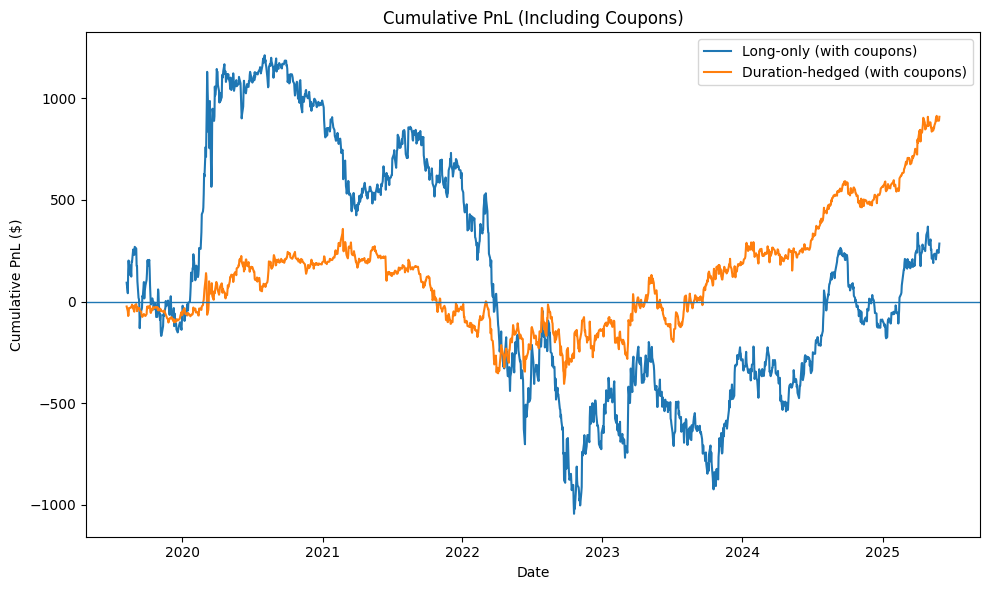

,profit,profit hedged
mean,$0.196,$0.625
std,$43.721,$21.194
min,$-321.204,$-98.341
25%,$-24.944,$-10.530
50%,$-0.883,$0.190
75%,$23.938,$10.980
max,$276.272,$118.431


,pnl_long_only_cpn,pnl_hedged_cpn
quote date,,
2025-05-22,12.737,8.395
2025-05-23,14.351,-23.262
2025-05-27,-13.731,-0.643
2025-05-28,23.418,0.211
2025-05-29,22.291,19.194


In [36]:
# Align coupon payments to df's timeline
# Coupon dataframe should be indexed by quote date and have columns [207391, 207392]
cp = coupon_payments[[id_long, id_short]].copy()

# Make sure indexes are datetime and aligned
df = df.copy()
df.index = pd.to_datetime(df.index)
cp.index = pd.to_datetime(cp.index)

# Coupon paid on "next day" belongs to pnl from t -> t+1
df["cpn_long_next"]  = cp[id_long].reindex(df.index).shift(-1).fillna(0.0)
df["cpn_short_next"] = cp[id_short].reindex(df.index).shift(-1).fillna(0.0)

# Add coupon cashflows to daily PnL
# Long-only: receive coupons on the long bond
df["pnl_long_only_cpn"] = df["pnl_long_only"] + df["units_long"] * df["cpn_long_next"]

# Hedged: receive long coupons, pay coupons on the short
df["pnl_hedged_cpn"] = (
    df["pnl_hedged"]
    + df["units_long"]  * df["cpn_long_next"]
    - df["units_short"] * df["cpn_short_next"]
)

#Cumulative PnL with coupons
df["cum_pnl_long_only_cpn"] = df["pnl_long_only_cpn"].cumsum()
df["cum_pnl_hedged_cpn"]    = df["pnl_hedged_cpn"].cumsum()

plt.figure(figsize=(10,6))
plt.plot(df.index, df["cum_pnl_long_only_cpn"], label="Long-only (with coupons)")
plt.plot(df.index, df["cum_pnl_hedged_cpn"], label="Duration-hedged (with coupons)")
plt.axhline(0, linewidth=1)
plt.title("Cumulative PnL (Including Coupons)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.legend()
plt.tight_layout()
plt.show()

#Summary stats table (daily)
summary = (
    df[["pnl_long_only_cpn", "pnl_hedged_cpn"]]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .loc[["mean", "std", "min", "25%", "50%", "75%", "max"]]
)

summary.columns = ["profit", "profit hedged"]

# Display like the screenshot (currency formatting)
display(summary.style.format("${:,.3f}"))

# Optional: show last few rows (rounded)
display(
    df[["pnl_long_only_cpn", "pnl_hedged_cpn"]]
    .round(3)
    .tail()
)

***